# Pseudobulk Differential Gene Expression Analysis in InSituPy

This tutorial demonstrates how to perform pseudobulk differential gene expression (DGE) analysis using InSituPy. Pseudobulk analysis aggregates single-cell counts by sample and cell type, enabling statistical testing with established bulk RNA-seq methods.

**When to use pseudobulk analysis:**
- Comparing gene expression between experimental conditions
- Analyzing regional differences in spatial transcriptomics data
- When you have multiple biological replicates per condition

More information on why to use pseudobulking, can be found in [this `decoupler` tutorial](https://decoupler.readthedocs.io/en/latest/notebooks/scell/rna_psbk.html).

## 1. Setup and Data Loading

In [1]:
## The following code ensures that all functions and init files are reloaded before executions.
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

from insitupy.dataclasses.results import DiffExprResults

from insitupy import InSituExperiment
from insitupy._core.data import CACHE, InSituData
from insitupy.plotting import dual_foldchange_plot, volcano
from insitupy.preprocessing import pseudobulk
from insitupy.tools import pseudobulk_dge

c:\Users\ge37voy\AppData\Local\miniconda3\envs\insitupy\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load Xenium Data

Load preprocessed Xenium data containing spatial transcriptomics information with cell segmentation and annotations.

In [3]:
# Update this path to your data location
data_path = Path(CACHE / "out/demo_insitupy_project")
xd = InSituData.read(data_path)
xd.load_all(skip="transcripts")  # Load all data except transcript coordinates
xd

InSituData
Method:		Xenium
Slide ID:	0001879
Sample ID:	Replicate 1
Path:		C:\Users\ge37voy\.cache\InSituPy\out\demo_insitupy_project

    ➤ images
       CD20:	(25778, 35416)
       HE:	(25778, 35416, 3)
       HER2:	(25778, 35416)
       nuclei:	(25778, 35416)
    ➤ cells
       MultiCellData with main layer 'main'
           matrix
               AnnData object with n_obs × n_vars = 156447 × 297
               obs: 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_genes_by_counts', 'n_genes', 'leiden', 'cell_type_dc_sub_final', 'cell_type_publ'
               var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
               uns: 'cell_type_dc_sub_final_colors', 'cell_type_publ_colors', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap'
               obsm: 'X_pca', 'X_umap', 'annotations', 'regions', 'spatial'
             

## 2. Create InSituExperiment from Regions

Since we do not actually have multiple samples in this dataset, we will create a dummy multi-sample TMA dataset in this step. For this, we will use `InSituExperiment`s `crop` function based on regions resembling a TMA core layout.

In [4]:
exp = InSituExperiment.from_regions(
    data=xd,
    region_key="TMA"  # Column in annotations containing region IDs
)

In [5]:
exp

InSituExperiment with 6 samples:
           uid  CITAR slide_id    sample_id region_key region_name
0     15ea3d05  ++-++  0001879  Replicate 1        TMA         A-1
1     8f4f542b  ++-++  0001879  Replicate 1        TMA         A-2
2     00532306  ++-++  0001879  Replicate 1        TMA         A-3
3     73a09855  ++-++  0001879  Replicate 1        TMA         B-1
4     0eb96d16  ++-++  0001879  Replicate 1        TMA         B-2
5     d91d4b01  ++-++  0001879  Replicate 1        TMA         B-3

Saving the `InSituExperiment` data.

In [6]:
exp.saveas(CACHE / "out/test_tma")

  0%|          | 0/6 [00:00<?, ?it/s]2025-11-13 16:59:50 | [INFO] Created 4 records
2025-11-13 16:59:50 | [INFO] Created 2 records
2025-11-13 16:59:50 | [INFO] Created 2 records
2025-11-13 16:59:50 | [INFO] Created 1 records
2025-11-13 16:59:50 | [INFO] Created 1 records
2025-11-13 16:59:50 | [INFO] Created 1 records
 17%|█▋        | 1/6 [00:05<00:29,  5.98s/it]2025-11-13 16:59:55 | [INFO] Created 1 records
2025-11-13 16:59:55 | [INFO] Created 1 records
2025-11-13 16:59:55 | [INFO] Created 1 records
2025-11-13 16:59:55 | [INFO] Created 1 records
 33%|███▎      | 2/6 [00:10<00:21,  5.36s/it]2025-11-13 16:59:59 | [INFO] Created 1 records
2025-11-13 16:59:59 | [INFO] Created 1 records
2025-11-13 16:59:59 | [INFO] Created 1 records
2025-11-13 16:59:59 | [INFO] Created 1 records
2025-11-13 16:59:59 | [INFO] Created 1 records
 50%|█████     | 3/6 [00:15<00:14,  4.97s/it]2025-11-13 17:00:05 | [INFO] Created 1 records
2025-11-13 17:00:05 | [INFO] Created 1 records
2025-11-13 17:00:05 | [INFO] 

## 3. Define Experimental Conditions

⚠️ **Important:** This tutorial uses dummy conditions for demonstration. In a real analysis, conditions should reflect meaningful biological groups (e.g., treatment vs. control, disease vs. healthy).

Add metadata specifying which condition each sample belongs to:

In [6]:
# Assign conditions: first 3 regions to condition A, last 3 to condition B
exp.add_metadata_column(
    column_name="condition",
    values=["A", "A", "A", "B", "B", "B"]
)

In [7]:
# Verify metadata structure
exp.metadata

You are accessing a copy of the metadata. Changes to this DataFrame will not affect the internal metadata. Use `add_metadata_column()` or `append_metadata()` to add new information to the metadata.


,uid,slide_id,sample_id,region_key,region_name,condition
0,a9ca1204,0001879,Replicate 1,TMA,A-1,A
1,ae9c547f,0001879,Replicate 1,TMA,A-2,A
2,4a6f9a1d,0001879,Replicate 1,TMA,A-3,A
3,86dfa8d6,0001879,Replicate 1,TMA,B-1,B
4,656f2f3f,0001879,Replicate 1,TMA,B-2,B
5,d7027ec3,0001879,Replicate 1,TMA,B-3,B


## 4. Generate Pseudobulk Data

Aggregate single-cell counts into pseudobulk samples. This creates one pseudobulk profile per (sample × cell type) combination.

**Key parameters:**
- `celltype_col`: Cell type annotation column to aggregate by
- `counts_layer`: Raw count matrix layer (use unnormalized counts)
- `metadata_to_transfer`: Experimental design variables to include
- `calculate_neighbors`: Determines whether or not to calculate the pseudobulk data of the neighboring cells.

For detailed information, see the [decoupler pseudobulk documentation](https://decoupler.readthedocs.io/en/latest/notebooks/scell/rna_psbk.html).

### Generating pseudobulk of the target cells only

Using `calculate_neighbors=False` we can calculate the pseudobulk profiles of the target cells only.

In [8]:
pdata = pseudobulk(
    exp=exp,
    celltype_col='cell_type_dc_sub_final',
    cells_layer='main',
    counts_layer='counts',  # Use raw counts, not normalized
    calculate_neighbors=False,
    metadata_to_transfer="condition"
)

In [9]:
# Inspect pseudobulk structure
pdata

AnnData object with n_obs × n_vars = 73 × 297
    obs: 'uid', 'cell_type_dc_sub_final', 'psbulk_cells', 'psbulk_counts', 'condition', 'obs_type'
    uns: 'pseudobulk_settings'
    layers: 'psbulk_props'

In [10]:
# View sample metadata
pdata.obs

,uid,cell_type_dc_sub_final,psbulk_cells,psbulk_counts,condition,obs_type
a9ca1204_B cells,a9ca1204,B cells,86.0,12128.0,A,cells
a9ca1204_Breast cancer subtype 1,a9ca1204,Breast cancer subtype 1,568.0,132467.0,A,cells
a9ca1204_Breast cancer subtype 2,a9ca1204,Breast cancer subtype 2,76.0,10725.0,A,cells
a9ca1204_Breast cancer subtype 3,a9ca1204,Breast cancer subtype 3,50.0,13919.0,A,cells
a9ca1204_Breast cancer subtype 4,a9ca1204,Breast cancer subtype 4,2379.0,528355.0,A,cells
...,...,...,...,...,...,...
d7027ec3_Endothelial cells,d7027ec3,Endothelial cells,218.0,38530.0,B,cells
d7027ec3_Macrophages,d7027ec3,Macrophages,459.0,84097.0,B,cells
d7027ec3_Smooth muscle cells,d7027ec3,Smooth muscle cells,81.0,12949.0,B,cells
d7027ec3_Stromal cells,d7027ec3,Stromal cells,633.0,146404.0,B,cells


### Taking Neighborhood Effects into account

Imaging-based spatial transcriptomics methods (e.g., Xenium, MERSCOPE) assign transcripts to cells through segmentation, a process prone to boundary errors. Misassigned transcripts can contaminate cell expression profiles, particularly when neighboring cells have distinct expression patterns.

To assess potential neighborhood contamination, set `calculate_neighbors=True` in the `pseudobulk` function. This returns a second pseudobulk dataset (`pdata_nb`) aggregating gene expression counts of cells that are within a certain radius (`neighbors_radius`) of either the target or the reference cells. This enables comparison between target cells and reference cells and their respective microenvironment to identify spillover effects.

In [11]:
pdata, pdata_nb = pseudobulk(
    exp=exp,
    celltype_col='cell_type_dc_sub_final',
    cells_layer='main',
    counts_layer='counts',  # Use raw counts, not normalized
    calculate_neighbors=True,
    neighbors_radius=20,
    metadata_to_transfer="condition"
)

In [12]:
pdata

AnnData object with n_obs × n_vars = 73 × 297
    obs: 'uid', 'cell_type_dc_sub_final', 'psbulk_cells', 'psbulk_counts', 'condition', 'obs_type'
    uns: 'pseudobulk_settings'
    layers: 'psbulk_props'

In [13]:
pdata_nb

AnnData object with n_obs × n_vars = 73 × 297
    obs: 'uid', 'psbulk_cells', 'psbulk_counts', 'cell_type_dc_sub_final', 'condition', 'obs_type'
    uns: 'pseudobulk_settings'
    layers: 'psbulk_props'

## 5. Differential Expression Analysis

### Quality Control and Filtering

Filter low-quality pseudobulk samples based on cell count and total reads. This ensures sufficient data for statistical testing.

**Filtering criteria:**
- `min_cells`: Minimum cells per pseudobulk sample (default: 10)
- `min_counts`: Minimum total counts per pseudobulk sample (default: 1000)

Samples failing these thresholds are excluded from analysis. Whether or not to show the QC plots can be determined with the `plot_qc` argument. 

### Setting up differential gene expression analysis

Perform DE testing using [PyDESeq2](https://pydeseq2.readthedocs.io/en/stable/index.html) with a Wald test. This identifies genes with significant expression changes between conditions.

**Analysis setup:**
- `dge_setup`: ["condition_column", "reference_group", "comparison_group"]
- Tests are performed separately for each cell type
- Uses DESeq2 normalization and dispersion estimation
- Wald test statistic: tests H₀: log2(fold change) = 0

In [14]:
# Define comparison: condition A vs B for Endothelial cells
dge_setup = ["condition", "A", "B"]  # [column, target, reference]
celltype_col = "cell_type_dc_sub_final"
celltype = "Endothelial cells"

Sample filtering QC:


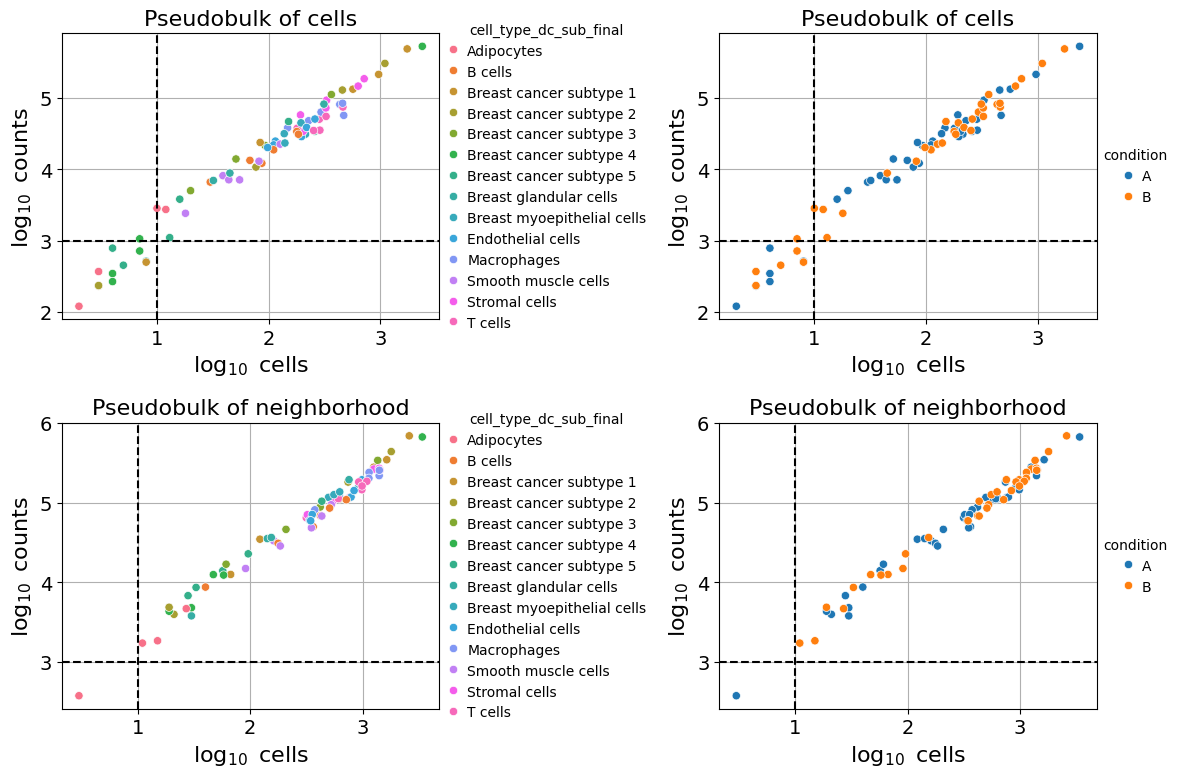

Filtered pseudobulk samples: 13 removed, 60 remaining (out of 73 total).
Filtered pseudobulk samples: 1 removed, 72 remaining (out of 73 total).
Feature filtering QC:


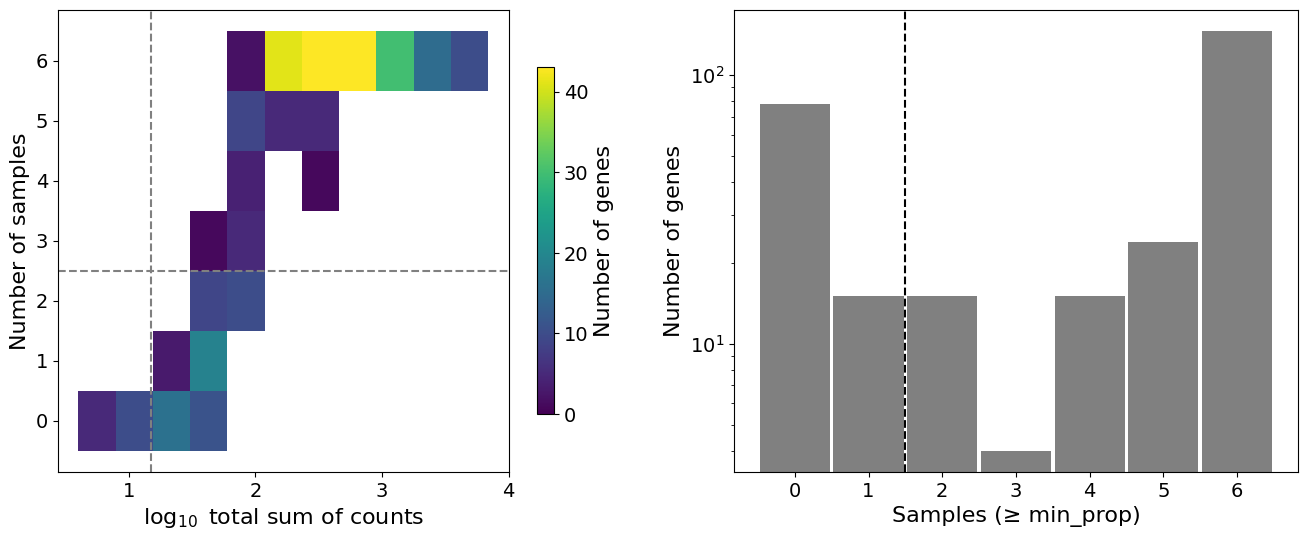

Filtered features: 94 removed, 203 remaining (out of 297 total).


In [15]:
# Run differential expression analysis
dge_results = pseudobulk_dge(
    pdata=pdata,
    pdata_nb=pdata_nb,
    dge_setup=dge_setup,
    celltype_col=celltype_col,
    celltype=celltype,
    plot_qc=True,  # Display QC plots
    min_cells=10,
    min_counts=1000
)

### Inspect Results

Results are returned as `DiffExprResults` object and contain, depending on the choice of `calculate_neighbors` following attributes:
- `.main`: Includes the DGE results of target vs. reference
- `.config`: Configurations of the differential gene expression analysis.
- With `calculate_neighbors=True`:
    - `.target_neighborhood`: DGE results of target cells vs. their neighboring cells
    - `.ref_neighborhood`: DGE results of reference cells vs. their neighboring cells

Each attribute is a pandas DataFrame with following columns:
- `log2foldchange`: Effect size (positive = upregulated in comparison group)
- `pvalue`: Unadjusted p-value from Wald test
- `padj`: Benjamini-Hochberg adjusted p-value (FDR)
- `baseMean`: Mean normalized expression across all samples
- `lfcSE`: Standard error of log2 fold change estimate

In [16]:
dge_results

<DiffExprResults main=203 genes, neighbors=True>

In [17]:
dge_results.target_neighborhood

,baseMean,log2foldchange,lfcSE,stat,pvalue,padj
TCEAL7,15.718131,0.029246,0.706394,0.041402,0.966975,0.983001
SERPINA3,169.857821,-1.068293,0.804259,-1.328294,0.184081,0.336653
OXTR,25.867383,-0.578630,1.008900,-0.573525,0.566289,0.699190
VOPP1,258.095754,0.201572,0.280058,0.719751,0.471678,0.629939
SLAMF7,42.654832,-1.381457,0.806041,-1.713880,0.086551,0.186913
...,...,...,...,...,...,...
BASP1,167.276937,-0.083483,0.456860,-0.182731,0.855009,0.936253
CCND1,1107.843556,0.006432,0.343226,0.018740,0.985048,0.994850
PIM1,54.493571,0.315380,0.436514,0.722497,0.469989,0.629939
GPR183,51.245005,-1.105145,0.489737,-2.256608,0.024033,0.067258


In [18]:
dge_results.target_neighborhood

,baseMean,log2foldchange,lfcSE,stat,pvalue,padj
TCEAL7,15.718131,0.029246,0.706394,0.041402,0.966975,0.983001
SERPINA3,169.857821,-1.068293,0.804259,-1.328294,0.184081,0.336653
OXTR,25.867383,-0.578630,1.008900,-0.573525,0.566289,0.699190
VOPP1,258.095754,0.201572,0.280058,0.719751,0.471678,0.629939
SLAMF7,42.654832,-1.381457,0.806041,-1.713880,0.086551,0.186913
...,...,...,...,...,...,...
BASP1,167.276937,-0.083483,0.456860,-0.182731,0.855009,0.936253
CCND1,1107.843556,0.006432,0.343226,0.018740,0.985048,0.994850
PIM1,54.493571,0.315380,0.436514,0.722497,0.469989,0.629939
GPR183,51.245005,-1.105145,0.489737,-2.256608,0.024033,0.067258


In [19]:
dge_results.ref_neighborhood

,baseMean,log2foldchange,lfcSE,stat,pvalue,padj
TCEAL7,38.239049,0.112318,0.627172,0.179087,0.857870,0.984517
SERPINA3,369.253368,-0.591137,0.813881,-0.726319,0.467643,0.713772
OXTR,32.981467,0.542059,0.456635,1.187071,0.235199,0.467345
VOPP1,336.178636,0.022524,0.231812,0.097165,0.922596,0.984517
SLAMF7,84.889624,-1.270426,0.481079,-2.640787,0.008271,0.039049
...,...,...,...,...,...,...
BASP1,256.730384,-0.480564,0.415231,-1.157339,0.247134,0.474292
CCND1,1234.364714,0.035665,0.370002,0.096392,0.923209,0.984517
PIM1,105.199901,-0.241432,0.430210,-0.561196,0.574664,0.815782
GPR183,87.687705,-1.171416,0.328587,-3.565012,0.000364,0.002736


In [23]:
dge_results.config

DiffExprConfigCollector(
  General:
    mode: pseudobulk
    method_params: Dictionary with following keys: dict_keys(['pseudobulk', 'deseq2'])
    cells_layer: None
    exclude_ambiguous_assignments: None
  Target:
    annotation: None
    cell_type: None
    region: None
    cell_number: None
    name: None
    metadata: None
  Reference:
    annotation: None
    cell_type: None
    region: None
    cell_number: None
    name: None
    metadata: None
)

In [24]:
# View top differentially expressed genes
dge_results.main.sort_values('log2foldchange', ascending=False).head(10)

,baseMean,log2foldchange,lfcSE,stat,pvalue,padj
STC1,42.618256,1.552160,0.619546,2.505320,0.012234,0.98202
TOP2A,53.314037,0.983508,0.758607,1.296467,0.194815,0.98202
CENPF,26.694345,0.822907,0.779076,1.056259,0.290850,0.98202
EPCAM,101.539657,0.719454,0.580242,1.239919,0.215005,0.98202
MLPH,59.747752,0.642235,0.739827,0.868087,0.385347,0.98202
S100A14,55.779857,0.604616,0.429980,1.406149,0.159680,0.98202
AIF1,80.345539,0.549303,0.279633,1.964370,0.049487,0.98202
MYH11,40.690712,0.536262,0.945131,0.567395,0.570446,0.98202
ANKRD30A,143.662662,0.528604,0.531122,0.995258,0.319611,0.98202
EIF4EBP1,32.833096,0.508238,0.494774,1.027214,0.304320,0.98202


## 6. Save and Load Results

Save results to disk for later analysis or sharing.

In [25]:
# Save results
output_dir = "out/pseudobulk_dge/"
dge_results.save(output_dir, overwrite=True)

In [26]:
# Load previously saved results
dr = DiffExprResults.read(output_dir)

## 7. Visualization

Visualize differential expression results to identify significant genes.

### Volcano Plot

Shows significance (y-axis) vs. effect size (x-axis). Points in the upper corners represent genes with large fold changes and high significance. Since none of the genes in this dummy experiment show a significant result in the adjusted p-values, we will plot for demonstration purposes the `"pvalue"` instead of `"padj"` (which is the default). 

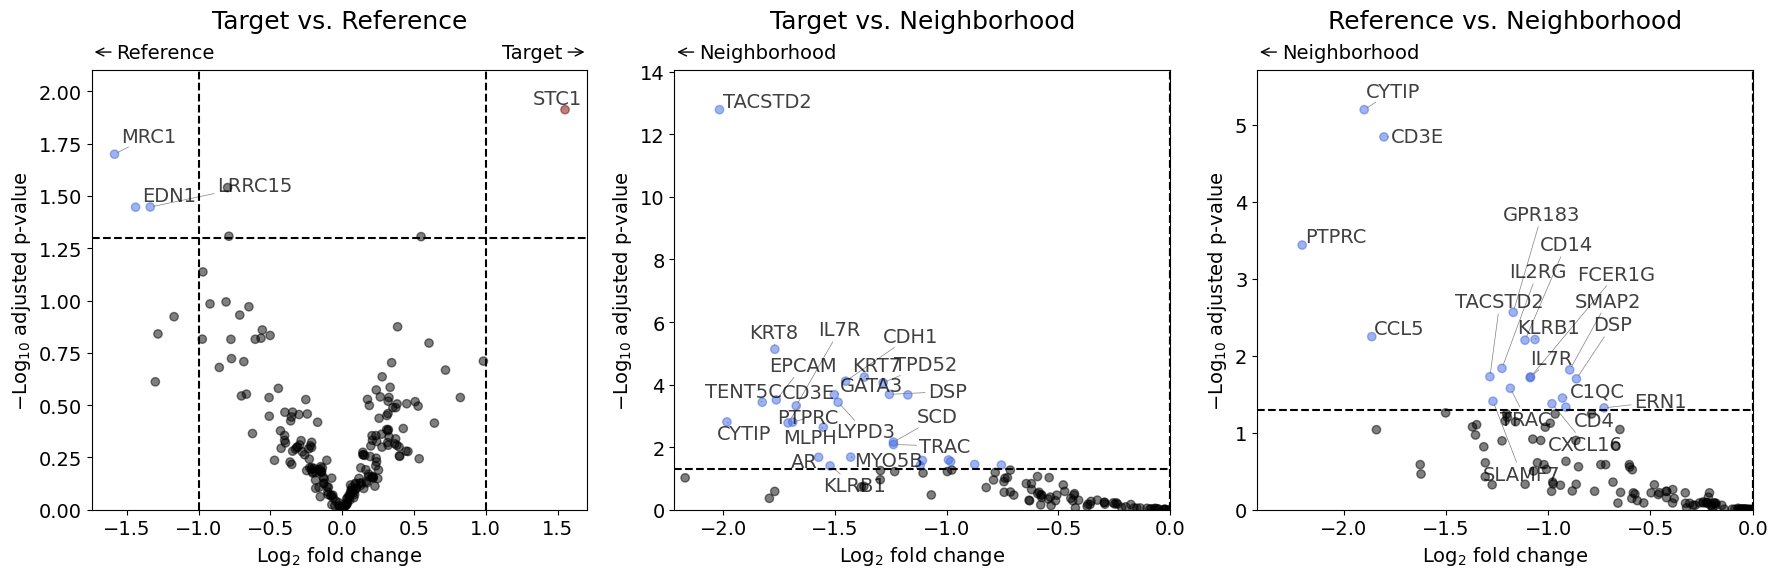

In [27]:
volcano(dr, pval_col="pvalue")

### Dual Fold Change Plot

Compares fold changes across two comparisons or displays expression patterns. Useful for identifying genes with consistent changes across multiple contrasts.

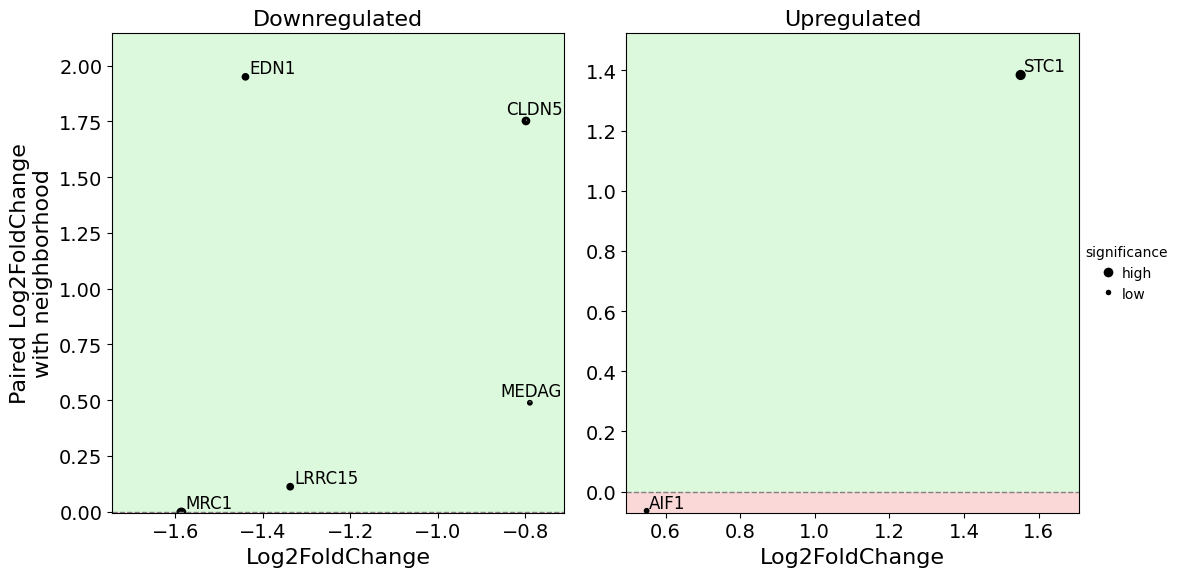

In [28]:
dual_foldchange_plot(
    dr,
    pval_col="pvalue",
    show_nonsignificant=False
    )